# Marketing Mix Modeling & Budget Optimization

This notebook estimates the incremental revenue contribution of multiple marketing channels and evaluates how budget reallocations impact overall revenue.

The goal is to identify which channels generate the highest marginal ROI and support data-driven media optimization decisions.

## Business Problem

Marketing budgets are distributed across channels such as Search, Social, Display, and CTV. 

Given a fixed total budget, how should funds be allocated to maximize revenue?

This analysis:
- Estimates incremental revenue contribution by channel
- Evaluates ROI
- Simulates reallocation scenarios

## Load Simulated Marketing Dataset

We load the previously generated multi-channel marketing dataset containing weekly spend, pricing, seasonality, and revenue.

In [44]:
import pandas as pd

df = pd.read_csv("../data/marketing_simulated_data.csv")
df.head()

,week,spend_search,spend_social,spend_display,spend_ctv,week_of_year,seasonality_index,price,m_search,m_social,m_display,m_ctv,m_ctv_lag1,revenue
0,2022-01-02,43916.849780,37956.551473,28071.093479,69393.688646,52,1.000000,50.391688,10.690076,10.544224,10.242531,11.147566,11.147566,893545.178516
1,2022-01-09,41689.222544,39130.294124,19357.163349,52721.985729,1,1.024107,49.945918,10.638022,10.574678,9.870869,10.872807,11.147566,917514.894509
2,2022-01-16,48678.382160,29497.124613,21876.264661,59076.770891,2,1.047863,51.743036,10.793011,10.292082,9.993203,10.986610,10.872807,950310.494214
3,2022-01-23,37832.029026,31444.907464,14192.036580,38554.419590,3,1.070921,50.724842,10.540938,10.356024,9.560507,10.559852,10.986610,934995.931093
4,2022-01-30,26196.934624,8374.996159,17927.542160,7774.455257,4,1.092945,50.507728,10.173436,9.033125,9.794149,8.958727,10.559852,952922.916011


## Feature Engineering & Time-Based Split

Revenue is modeled as a function of:
- Marketing spend
- Price
- Seasonality

We perform a time-based split to simulate training on past data and evaluating on future data.

In [45]:
y = df["revenue"]

X_raw = df[["spend_search", "spend_social", "spend_display", "spend_ctv", "price", "seasonality_index"]]

X_raw.head()

,spend_search,spend_social,spend_display,spend_ctv,price,seasonality_index
0,43916.849780,37956.551473,28071.093479,69393.688646,50.391688,1.000000
1,41689.222544,39130.294124,19357.163349,52721.985729,49.945918,1.024107
2,48678.382160,29497.124613,21876.264661,59076.770891,51.743036,1.047863
3,37832.029026,31444.907464,14192.036580,38554.419590,50.724842,1.070921
4,26196.934624,8374.996159,17927.542160,7774.455257,50.507728,1.092945


## Modeling Approach

Revenue is modeled as a function of:

- Log-transformed marketing spend 
- Lagged CTV impact 
- Price 
- Seasonality 

Models evaluated:
1. Linear regression using raw spend
2. Linear regression using log-transformed spend
3. Ridge regression (regularized model)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [47]:
model_raw = LinearRegression()
model_raw.fit(X_train_raw, y_train)
y_pred_raw = model_raw.predict(X_test_raw)
r2_raw = r2_score(y_test, y_pred_raw)
mae_raw = mean_absolute_error(y_test, y_pred_raw)

r2_raw, mae_raw

(0.978543953966961, 10485.668039094595)

### Interpretation

The baseline model demonstrates strong predictive performance. However, coefficient inspection reveals unstable channel attribution due to mis-specification of functional form and lag structure.

In [48]:
import pandas as pd

coef_table = pd.DataFrame({
    "feature": X_train_raw.columns,
    "coefficient": model_raw.coef_
})

coef_table

,feature,coefficient
0,spend_search,0.743101
1,spend_social,0.508949
2,spend_display,0.390357
3,spend_ctv,-0.288918
4,price,-369.690937
5,seasonality_index,883472.792930


## Corrected Model (Log-Transformed Spend & Lagged CTV)

Marketing impact typically exhibits diminishing returns. Therefore, we apply a log transformation to spend variables.

Additionally, CTV is modeled with a one-week lag to reflect delayed brand impact.

In [49]:
X_log = df[["m_search", "m_social", "m_display", "m_ctv_lag1", "price", "seasonality_index"]]

X_train_log = X_log.iloc[:split_idx]
X_test_log  = X_log.iloc[split_idx:]

### Model Performance

We evaluate predictive accuracy under the corrected specification.

In [50]:
model_log = LinearRegression()
model_log.fit(X_train_log, y_train)

y_pred_log = model_log.predict(X_test_log)

r2_log = r2_score(y_test, y_pred_log)
mae_log = mean_absolute_error(y_test, y_pred_log)

r2_log, mae_log

(0.9810274298290688, 9007.073556258412)

### Interpretation

The log-transformed model improves specification and stabilizes channel attribution. Coefficient signs align with economic intuition and expected media dynamics.

In [59]:
coef_table_log = pd.DataFrame({
    "feature": X_train_log.columns,
    "coefficient": model_log.coef_
})

coef_table_log

,feature,coefficient
0,m_search,22922.455737
1,m_social,9456.194535
2,m_display,5975.148244
3,m_ctv_lag1,29065.815971
4,price,-2281.655867
5,seasonality_index,881240.330554


In [52]:
import numpy as np
import pandas as pd

X_all = X_log.copy()

df["pred_revenue"] = model_log.predict(X_all)

df[["week", "revenue", "pred_revenue"]].head()

,week,revenue,pred_revenue
0,2022-01-02,893545.178516,900997.310899
1,2022-01-09,917514.894509,920132.795375
2,2022-01-16,950310.494214,930592.277821
3,2022-01-23,934995.931093,948783.820200
4,2022-01-30,952922.916011,936745.678290


## Channel Contribution Estimation

We estimate incremental contribution by setting each channel to zero and measuring the reduction in predicted revenue.

In [53]:
channels = ["m_search", "m_social", "m_display", "m_ctv_lag1"]

contrib = {}

for ch in channels:
    X_zero = X_all.copy()
    X_zero[ch] = 0  
    
    pred_full = model_log.predict(X_all)
    pred_zero = model_log.predict(X_zero)
    
    contrib[ch] = pred_full - pred_zero

contrib_df = pd.DataFrame(contrib)
contrib_df.head()

,m_search,m_social,m_display,m_ctv_lag1
0,245042.796620,99708.230980,61200.642596,324013.090573
1,243849.586332,99996.210300,58979.908488,324013.090573
2,247402.313592,97323.929259,59710.870751,316027.001571
3,241624.179772,97928.578739,57125.445069,319334.784564
4,233200.133087,85418.990039,58521.493728,306930.713605


## ROI Calculation

ROI is computed as:

Incremental Revenue / Total Spend

In [54]:
spend_map = {
    "m_search": "spend_search",
    "m_social": "spend_social",
    "m_display": "spend_display",
    "m_ctv_lag1": "spend_ctv"
}

summary_rows = []

for ch in channels:
    total_contrib = contrib_df[ch].sum()
    total_spend = df[spend_map[ch]].sum()
    roi = total_contrib / total_spend
    
    summary_rows.append({
        "channel": ch.replace("m_", "").replace("_lag1", "").upper(),
        "total_spend": total_spend,
        "modeled_incremental_revenue": total_contrib,
        "roi": roi
    })

roi_table = pd.DataFrame(summary_rows).sort_values("roi", ascending=False)
roi_table

,channel,total_spend,modeled_incremental_revenue,roi
3,CTV,7.657075e+06,4.871712e+07,6.362368
0,SEARCH,6.250370e+06,3.775622e+07,6.040638
1,SOCIAL,4.667392e+06,1.514586e+07,3.245036
2,DISPLAY,3.088528e+06,9.159983e+06,2.965808


## Budget Reallocation Simulation

We simulate shifting 10% of Display spend into CTV to evaluate the impact on total predicted revenue.

In [55]:
X_sim = X_log.copy()

display_reduction = 0.10 * df["spend_display"]

new_display_spend = df["spend_display"] - display_reduction
new_ctv_spend = df["spend_ctv"] + display_reduction

X_sim["m_display"] = np.log1p(new_display_spend)
X_sim["m_ctv_lag1"] = np.log1p(new_ctv_spend).shift(1).fillna(np.log1p(new_ctv_spend).iloc[0])

df["pred_revenue_reallocated"] = model_log.predict(X_sim)

baseline_total = df["pred_revenue"].sum()
reallocated_total = df["pred_revenue_reallocated"].sum()

baseline_total, reallocated_total, reallocated_total - baseline_total

(137068894.82787567, 137164735.3315919, 95840.50371623039)

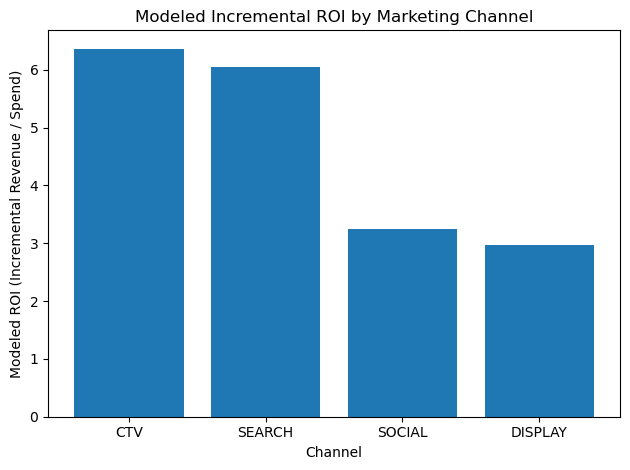

In [56]:
plt.figure()

plt.bar(roi_table["channel"], roi_table["roi"])

plt.xlabel("Channel")
plt.ylabel("Modeled ROI (Incremental Revenue / Spend)")
plt.title("Modeled Incremental ROI by Marketing Channel")

plt.tight_layout()
plt.show()

## Regularized Model (Ridge Regression)

To address potential multicollinearity, we estimate a Ridge regression model using standardized features.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

ridge_model = Ridge(alpha=10)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

r2_ridge, mae_ridge

(0.9680225511049236, 12901.685878491655)

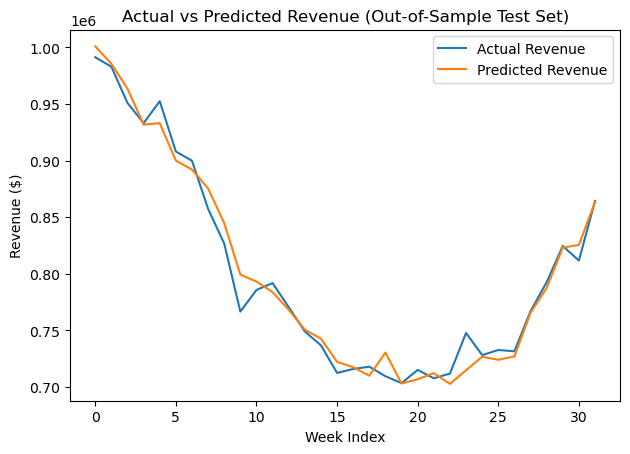

In [58]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(y_test.values, label="Actual Revenue")
plt.plot(y_pred_log, label="Predicted Revenue")

plt.xlabel("Week Index")
plt.ylabel("Revenue ($)")
plt.title("Actual vs Predicted Revenue (Out-of-Sample Test Set)")

plt.legend()
plt.tight_layout()
plt.show()

## Executive Summary

- Log transformation improved model specification.
- CTV and Search demonstrated highest modeled ROI.
- Reallocating budget toward higher-ROI channels increased total predicted revenue.
- Ridge regression did not outperform the correctly specified OLS model.